# M2K Bollinger Band mean-reversion, 30-minute bars (Tradovate exchange)

Same strategy and methodology as `bollinger_mean_reversion_mes_30m.ipynb`,
which found the **strongest walk-forward-confirmed result in this entire
research program** (`trade_sharpe_lb=+0.0831`, more than 3x the previous best
in this repo). This notebook re-runs the identical escalating-refinement
process -- indicator hyperparameters, then SL/TP, then direction, then
holdout, then walk-forward if promising -- on M2K at
30-minute bars.

**Mechanism** (`BollingerMeanReversionStrategy`): fades an extension to the
outer Bollinger Band (touch lower band -> long, touch upper -> short), fixed
fractional-distance stop-loss/take-profit (`sl_percent`/`tp_percent`).


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange.event_log import OrderFilled
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import BollingerMeanReversionStrategy, StrategyDirection
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/breakout


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


DISPLAY_SYMBOL = "M2K"
SYMBOL = "M2K/USD"
INTERVAL = 30
UNIT_OF_TIME = "minute"

data_path = _find_upwards("apps/backtester/datasets/databento/M2K_c_0_1m.parquet", start=Path(cwd))
ohlc = load_1m_parquet_resampled(data_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
print(f"Bars: {len(ohlc)}  span: {ohlc.index[0]} -> {ohlc.index[-1]}")


Bars: 84306  span: 2019-05-05 22:29:59.999000 -> 2026-07-13 07:29:59.999000


## Phase 1: grid the indicator's own hyperparameters (bb_length x bb_std_dev)

`sl_percent=0.01`, `tp_percent=0.01` fixed at placeholder values for this
pass -- tuned properly in Phase 2. `direction=both`.


In [3]:
BB_LENGTH_CANDIDATES = [10, 20, 30, 50]
BB_STD_DEV_CANDIDATES = [1.5, 2.0, 2.5, 3.0]
PLACEHOLDER_SL_PERCENT = 0.01
PLACEHOLDER_TP_PERCENT = 0.01
DEPOSIT_USD = 50_000


def run_bmr_backtest(ohlc_slice: pd.DataFrame, bb_length: int, bb_std_dev: float, sl_percent: float, tp_percent: float,
                      key: str, direction: StrategyDirection = StrategyDirection.both):
    lower, _middle, upper = Indicators.bollinger_bands(ohlc_slice, length=bb_length, std_dev=bb_std_dev)

    market = Market()
    market.add_market(symbol=SYMBOL, df=ohlc_slice)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="bb_lower", df=lower)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="bb_upper", df=upper)
    market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(weight=1.0, strategy=BollingerMeanReversionStrategy(
            key=key, market=market, symbol=SYMBOL, bb_lower_key="bb_lower", bb_upper_key="bb_upper",
            sl_percent=sl_percent, tp_percent=tp_percent, direction=direction,
        )),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=[SYMBOL], periods_per_year=252)

    market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_middleware, drawdown_middleware])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


def _summarize(bt, drawdown_mw, **extra_cols):
    summary = bt.reporter.summary["algo"]
    total_fees = sum(e.fees_volume for e in bt.exchange.event_log.get_events() if isinstance(e, OrderFilled))
    row = {**extra_cols}
    row.update({
        "net_return_percent": summary["net_return_percent"], "sharpe_ratio": summary["sharpe_ratio"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "closed_trades": summary["closed_trades"],
        "trades_per_year": round(summary["closed_trades"] / 7.2, 1), "win_rate_percent": summary["win_rate_percent"],
        "profit_factor": summary["profit_factor"], "r_multiple_expectancy": summary["r_multiple_expectancy"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "total_fees_usd": total_fees, "account_failed": drawdown_mw.account_failed,
    })
    return row


grid1_rows = []
grid1_backtests = {}
_t0 = time.time()
for bb_length in BB_LENGTH_CANDIDATES:
    for bb_std_dev in BB_STD_DEV_CANDIDATES:
        bt, drawdown_mw = run_bmr_backtest(ohlc, bb_length, bb_std_dev, PLACEHOLDER_SL_PERCENT, PLACEHOLDER_TP_PERCENT,
                                             key=f"BMR_ind_{bb_length}_{bb_std_dev}")
        grid1_backtests[(bb_length, bb_std_dev)] = (bt, drawdown_mw)
        grid1_rows.append(_summarize(bt, drawdown_mw, bb_length=bb_length, bb_std_dev=bb_std_dev))
    print(f"bb_length={bb_length} done, {time.time() - _t0:.0f}s elapsed", flush=True)

grid1_results = pd.DataFrame(grid1_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print("\nphase 1 grid done in " + f"{time.time() - _t0:.0f}s\n")
print(grid1_results.to_string())


bb_length=10 done, 44s elapsed


bb_length=20 done, 90s elapsed


bb_length=30 done, 136s elapsed


bb_length=50 done, 174s elapsed



phase 1 grid done in 174s

    bb_length  bb_std_dev  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
0          30         3.0            2.768848      0.078727              -34.0099         1726.0            239.7         55.272306       1.247112               0.110029              1.047851           7.814384        12102.09           False
1          50         2.5          -20.880943     -0.145926              -43.6181         1956.0            271.7         47.443763       0.910894              -0.046627              1.014067           2.467657        15277.08           False
2          20         3.0          -23.911672     -0.187496              -44.8363         1646.0            228.6         57.047388       1.340417               0.145567              0.994072          -0.904559        10428.60           False


### Heatmaps: Sharpe ratio and net return across (bb_length, bb_std_dev)


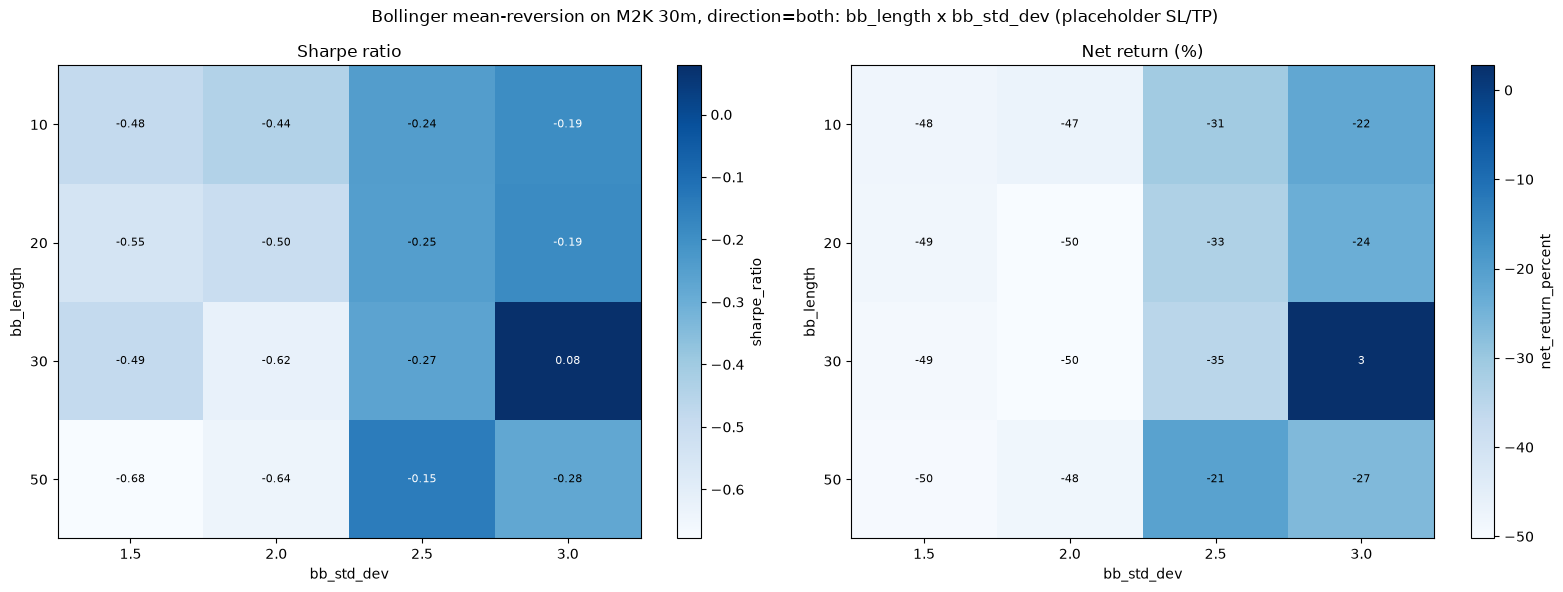

In [4]:
def _plot_heatmap(ax, pivot: pd.DataFrame, title: str, fmt: str, xlabel: str, ylabel: str):
    values = pivot.values.astype(float)
    vmin, vmax = np.nanmin(values), np.nanmax(values)
    span = vmax - vmin if vmax > vmin else 1.0
    im = ax.imshow(values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)), labels=[str(c) for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)), labels=[str(i) for i in pivot.index])
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            normalized = (val - vmin) / span
            ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=8,
                    color="white" if normalized > 0.6 else "black")
    return im


sharpe_pivot = grid1_results.pivot(index="bb_length", columns="bb_std_dev", values="sharpe_ratio")
return_pivot = grid1_results.pivot(index="bb_length", columns="bb_std_dev", values="net_return_percent")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im0 = _plot_heatmap(axes[0], sharpe_pivot, "Sharpe ratio", ".2f", "bb_std_dev", "bb_length")
fig.colorbar(im0, ax=axes[0], label="sharpe_ratio")
im1 = _plot_heatmap(axes[1], return_pivot, "Net return (%)", ".0f", "bb_std_dev", "bb_length")
fig.colorbar(im1, ax=axes[1], label="net_return_percent")
fig.suptitle("Bollinger mean-reversion on M2K 30m, direction=both: bb_length x bb_std_dev (placeholder SL/TP)")
fig.tight_layout()
plt.show()


## Phase 2: grid SL/TP on the best (bb_length, bb_std_dev) combo

Holding the indicator shape fixed at Phase 1's winner, grids `sl_percent` x
`tp_percent` directly.


In [5]:
best_bb_length, best_bb_std_dev = grid1_results.iloc[0][["bb_length", "bb_std_dev"]]
best_bb_length = int(best_bb_length)
best_bb_std_dev = float(best_bb_std_dev)
print(f"Phase 1 winner: bb_length={best_bb_length}, bb_std_dev={best_bb_std_dev}")

SL_PERCENT_CANDIDATES = [0.005, 0.01, 0.015, 0.02]
TP_PERCENT_CANDIDATES = [0.0025, 0.005, 0.0075, 0.01]

grid2_rows = []
grid2_backtests = {}
_t0 = time.time()
for sl_percent in SL_PERCENT_CANDIDATES:
    for tp_percent in TP_PERCENT_CANDIDATES:
        bt, drawdown_mw = run_bmr_backtest(ohlc, best_bb_length, best_bb_std_dev, sl_percent, tp_percent,
                                             key=f"BMR_sltp_{sl_percent}_{tp_percent}")
        grid2_backtests[(sl_percent, tp_percent)] = (bt, drawdown_mw)
        grid2_rows.append(_summarize(bt, drawdown_mw, sl_percent=sl_percent, tp_percent=tp_percent))
    print(f"sl_percent={sl_percent} done, {time.time() - _t0:.0f}s elapsed", flush=True)

grid2_results = pd.DataFrame(grid2_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print("\nphase 2 grid done in " + f"{time.time() - _t0:.0f}s\n")
print(grid2_results.to_string())


Phase 1 winner: bb_length=30, bb_std_dev=3.0


sl_percent=0.005 done, 50s elapsed


sl_percent=0.01 done, 92s elapsed


sl_percent=0.015 done, 129s elapsed


sl_percent=0.02 done, 171s elapsed



phase 2 grid done in 171s

    sl_percent  tp_percent  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
0        0.010      0.0100            2.768848      0.078727              -34.0099         1726.0            239.7         55.272306       1.247112               0.110029              1.047851           7.814384        12102.09           False
1        0.010      0.0075          -25.135152     -0.230569              -44.3169         1960.0            272.2         61.377551       1.201332               0.077408              0.997318          -0.323218        11899.16           False
2        0.015      0.0050          -34.140137     -0.369551              -43.7057         1957.0            271.8         77.772100       1.177160               0.039106              0.970598          -2.960779        11263.98           Fa

### Heatmaps: Sharpe ratio and net return across (sl_percent, tp_percent)


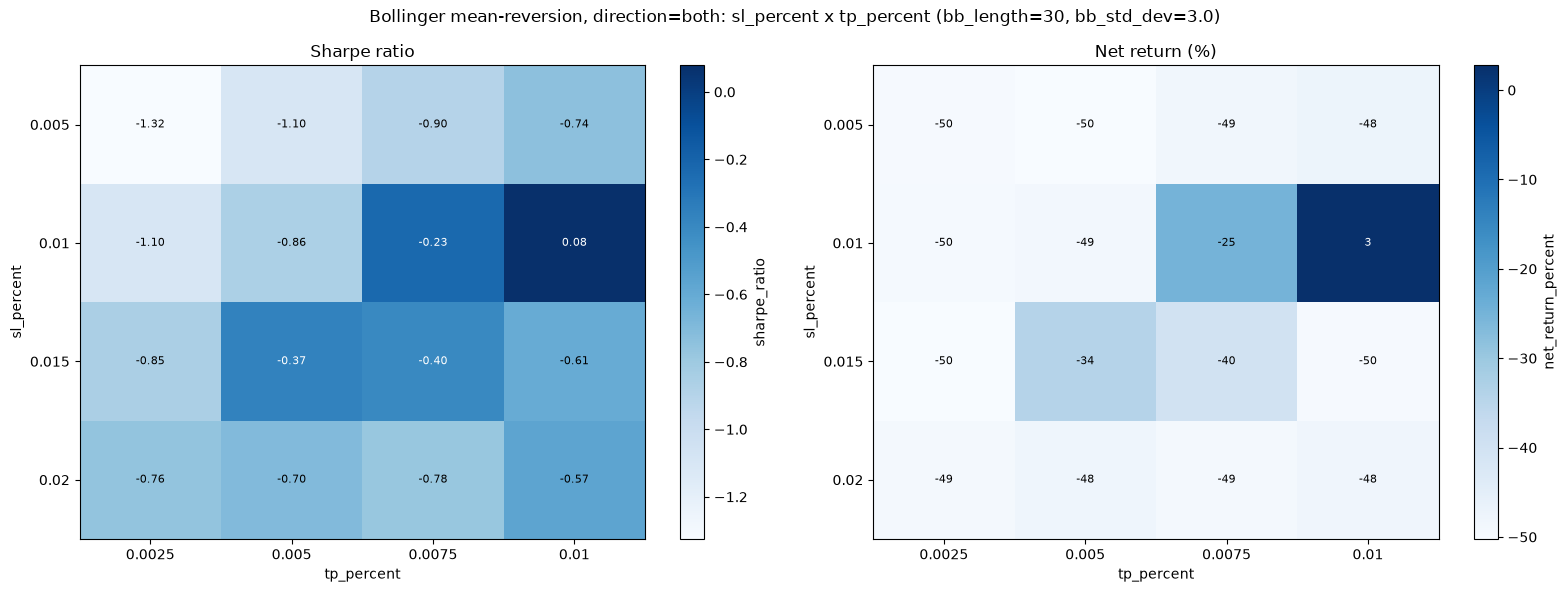

In [6]:
sharpe_pivot2 = grid2_results.pivot(index="sl_percent", columns="tp_percent", values="sharpe_ratio")
return_pivot2 = grid2_results.pivot(index="sl_percent", columns="tp_percent", values="net_return_percent")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im0 = _plot_heatmap(axes[0], sharpe_pivot2, "Sharpe ratio", ".2f", "tp_percent", "sl_percent")
fig.colorbar(im0, ax=axes[0], label="sharpe_ratio")
im1 = _plot_heatmap(axes[1], return_pivot2, "Net return (%)", ".0f", "tp_percent", "sl_percent")
fig.colorbar(im1, ax=axes[1], label="net_return_percent")
fig.suptitle(f"Bollinger mean-reversion, direction=both: sl_percent x tp_percent (bb_length={best_bb_length}, bb_std_dev={best_bb_std_dev})")
fig.tight_layout()
plt.show()


## Detailed report for the overall best combo

Full HTML summary (year-by-year split) and equity/drawdown charts for the
best (bb_length, bb_std_dev, sl_percent, tp_percent) combo across both grids.


Best combo: bb_length=30, bb_std_dev=3.0, sl_percent=0.01, tp_percent=0.01
Candles Processed: 84305
Account failed (drawdown breach): False


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,M2K/USD,description
🏦 Gross Return %,102.7688,87.0376,100.1954,94.3664,96.6053,100.6826,87.1111,113.4581,129.9049,188.7120,"Ending NAV as a percent of starting capital (100 + net_return_percent) -- not ""return before fees""."
💰 Net Return %,2.7688,-12.9624,0.1954,-5.6336,-3.3947,0.6826,-12.8889,13.4581,29.9049,88.7120,Your actual gain over the backtest window.
📉 Max Drawdown %,-34.0099,-14.6937,-13.3783,-13.3487,-14.8711,-18.5857,-15.0670,-9.3272,-4.9670,-43.6096,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
⏱️ Max Drawdown Duration (days),2583,210,352,333,280,194,346,77,39,1097,How long it took to recover the loss. Shorter is better.
📊 Sharpe Ratio,0.0787,-1.5409,0.0712,-0.3416,-0.1384,0.0979,-0.8491,0.8454,3.4016,0.3891,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
📊 Sortino Ratio,0.1111,-2.0013,0.0977,-0.4825,-0.1935,0.1400,-1.1191,1.2344,6.4163,0.5585,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
🌪️ Annualized Volatility %,10.9663,9.1848,12.0100,10.2012,12.0201,11.2856,10.5342,11.0312,10.1478,21.7514,How much the equity curve swings per year. Lower = smoother.
📈 CAGR %,0.3803,-19.0337,0.1954,-5.6486,-3.4039,0.6845,-12.8889,13.4974,64.0166,9.2282,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
📐 Calmar Ratio,0.0112,-1.2954,0.0146,-0.4232,-0.2289,0.0368,-0.8554,1.4471,12.8883,0.2116,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
🔁 Recovery Factor,0.0814,-0.8822,0.0146,-0.4220,-0.2283,0.0367,-0.8554,1.4429,6.0207,2.0342,Total net profit ÷ max drawdown. >2 solid.


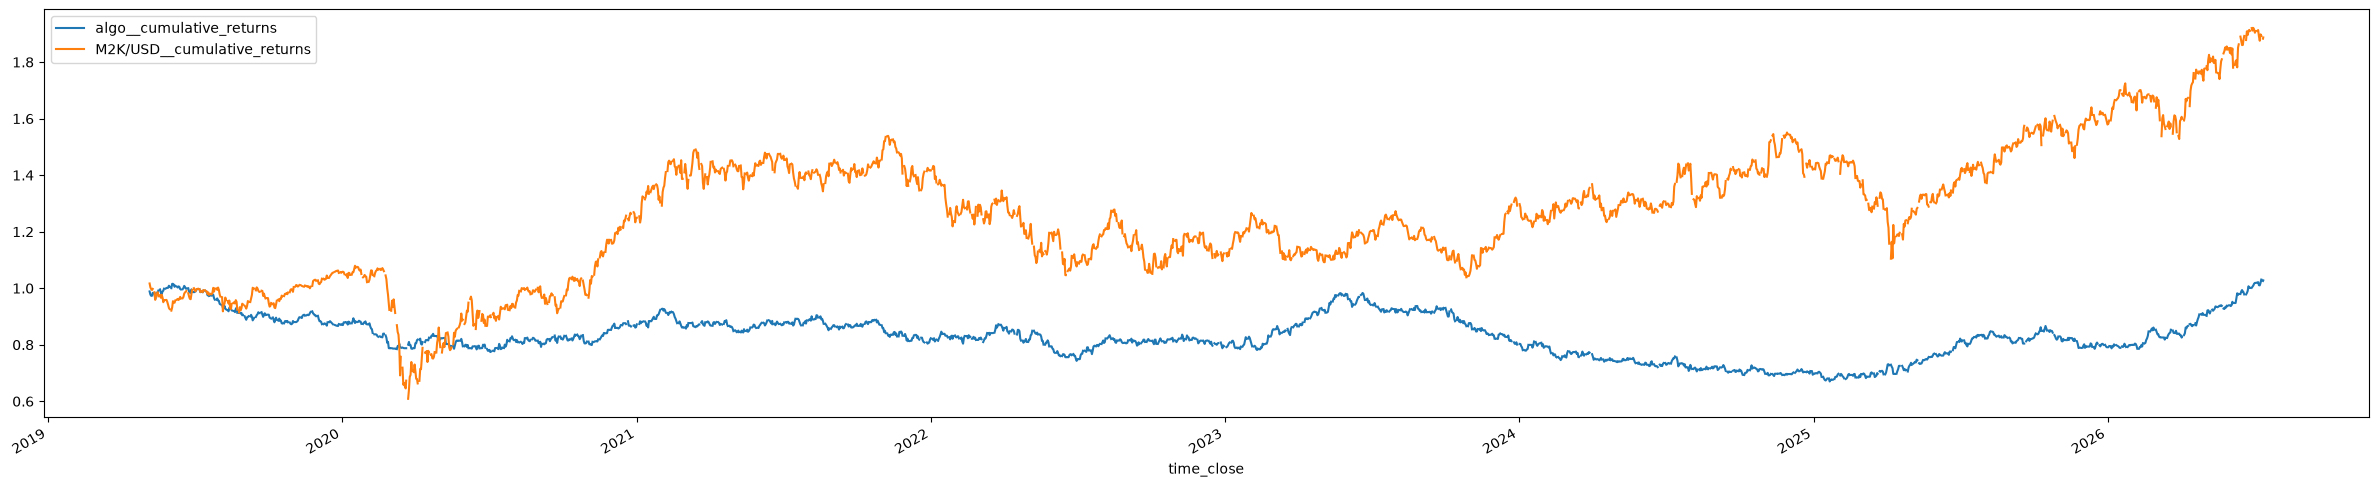

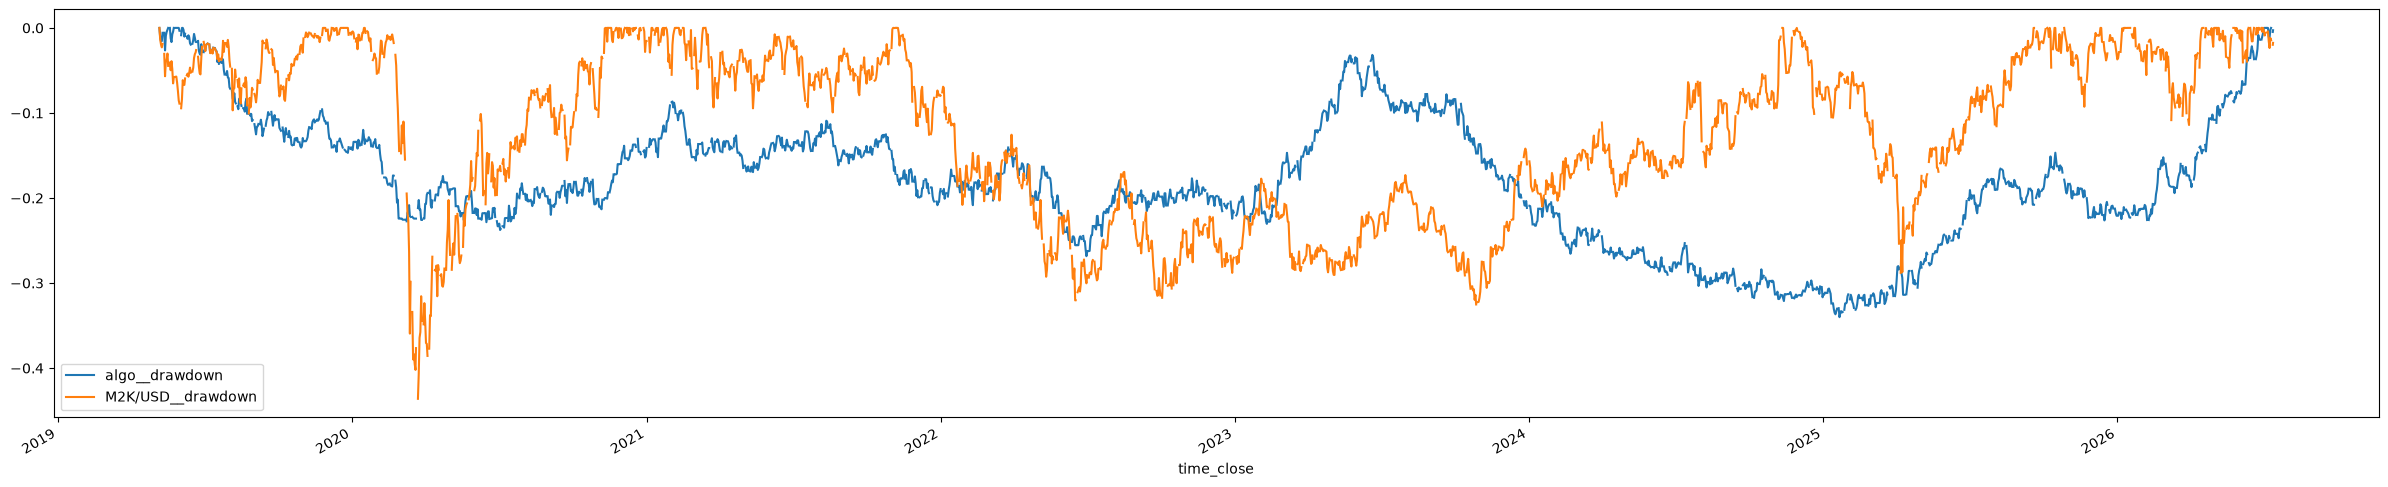

In [7]:
best_sl_percent, best_tp_percent = grid2_results.iloc[0][["sl_percent", "tp_percent"]]
best_sl_percent = float(best_sl_percent)
best_tp_percent = float(best_tp_percent)
print(f"Best combo: bb_length={best_bb_length}, bb_std_dev={best_bb_std_dev}, sl_percent={best_sl_percent}, tp_percent={best_tp_percent}")
best_backtest, best_drawdown_mw = grid2_backtests[(best_sl_percent, best_tp_percent)]

print("Candles Processed:", best_backtest.market.current["num"])
print("Account failed (drawdown breach):", best_drawdown_mw.account_failed)

display(HTML(best_backtest.reporter.summary_html_table(split="Y")))

if best_backtest.reporter.merged is not None:
    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns",
    ], figsize=(30, 6))

    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown",
    ], figsize=(30, 6))


## Direction comparison: both vs. long-only vs. short-only

Holding (bb_length, bb_std_dev, sl_percent, tp_percent) fixed at the overall
best combo, re-runs with `direction=long` and `direction=short`.


In [8]:
direction_rows = []
direction_backtests = {}
for direction in [StrategyDirection.both, StrategyDirection.long, StrategyDirection.short]:
    bt, drawdown_mw = run_bmr_backtest(ohlc, best_bb_length, best_bb_std_dev, best_sl_percent, best_tp_percent,
                                         key=f"BMR_dir_{direction.value}", direction=direction)
    direction_backtests[direction] = (bt, drawdown_mw)
    direction_rows.append({"direction": direction.value, **_summarize(bt, drawdown_mw)})

direction_df = pd.DataFrame(direction_rows).set_index("direction")
print(direction_df.to_string())


           net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
direction                                                                                                                                                                                                                         
both                 2.768848      0.078727              -34.0099         1726.0            239.7         55.272306       1.247112               0.110029              1.047851           7.814384        12102.09           False
long               -22.997400     -0.247724              -32.5480         1073.0            149.0         54.147251       1.180894               0.082945              0.978649          -3.574665         7549.36           False
short                2.336300      0.068290              -27.7182          950.0            

## Holdout check: does the best (combo, direction) survive a train/test split?

Uses whichever of both/long/short scored highest above.


In [9]:
best_direction_label = direction_df["sharpe_ratio"].idxmax()
best_direction = StrategyDirection(best_direction_label)
print(f"Best direction: {best_direction_label}")

split_idx = int(len(ohlc) * 0.75)
split_date = ohlc.index[split_idx]
print(f"train/test split at {split_date}  ({split_idx} train bars, {len(ohlc) - split_idx} test bars)")

train_ohlc, test_ohlc = ohlc.loc[:split_date], ohlc.loc[split_date:]


def trade_sharpe_lb(trades: list, z: float = 1.645) -> tuple[float, float, int]:
    '''Lo (2002) Sharpe lower bound over a strategy's per-trade returns: point
    estimate minus z standard errors, SE(SR) ~= sqrt((1 + SR^2/2) / N). Returns
    (trade_sharpe, trade_sharpe_lb, n) -- NaN Sharpes if fewer than 2 trades or a
    zero-variance trade set (can't estimate a standard error from either).'''
    pnls = np.array([t.pnl for t in trades])
    n = len(pnls)
    if n < 2 or pnls.std(ddof=1) == 0:
        return float("nan"), float("nan"), n
    sr = pnls.mean() / pnls.std(ddof=1)
    se = np.sqrt((1 + sr**2 / 2) / n)
    return sr, sr - z * se, n


holdout_rows = []
for label, ohlc_slice in [
    ("FULL", ohlc),
    ("TRAIN (75%)", train_ohlc),
    ("TEST (last 25%, unseen)", test_ohlc),
]:
    bt, drawdown_mw = run_bmr_backtest(ohlc_slice, best_bb_length, best_bb_std_dev, best_sl_percent, best_tp_percent,
                                         key=f"BMR_holdout_{label}", direction=best_direction)
    strategy = bt.portfolio.weighted_strategies[0].strategy
    trade_sharpe, sr_lb, n_trades = trade_sharpe_lb(strategy.trade_history)
    summary = bt.reporter.summary["algo"]
    holdout_rows.append({
        "window": label, "trades": n_trades, "win_rate_percent": summary["win_rate_percent"],
        "trade_sharpe": trade_sharpe, "trade_sharpe_lb": sr_lb,
        "account_sharpe": summary["sharpe_ratio"], "net_return_percent": summary["net_return_percent"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "account_failed": drawdown_mw.account_failed,
    })

holdout_df = pd.DataFrame(holdout_rows).set_index("window")
print(holdout_df.to_string())


Best direction: both
train/test split at 2024-09-23 13:59:59.999000  (63229 train bars, 21077 test bars)


                         trades  win_rate_percent  trade_sharpe  trade_sharpe_lb  account_sharpe  net_return_percent  dollar_profit_factor  dollar_expectancy  max_drawdown_percent  account_failed
window                                                                                                                                                                                             
FULL                       1726         55.272306      0.110605         0.070889        0.078727            2.768848              1.047851           7.814384              -34.0099           False
TRAIN (75%)                1305         54.022989      0.085188         0.039569       -0.339845          -28.997849              0.979301          -3.559851              -30.9715           False
TEST (last 25%, unseen)     420         59.285714      0.193693         0.112676        1.524781           51.946379              1.342011          69.466649              -10.0409           False


## Findings

**Weak, fragile, and inconsistent with this program's established
long-only pattern -- does not look like a real, reliable edge, and is not a
good candidate for a diversifying third portfolio signal.**

**Phase 1 is dominated by drawdown breaches**: only 1 of 16 combos was even
net-positive (`bb_length=30, bb_std_dev=3.0`, Sharpe 0.079 -- barely above
zero), and **8 of 16 combos breached the drawdown middleware outright**.
Phase 2 is worse: **12 of 16 combos breached the drawdown middleware**. This
is a far more fragile parameter surface than MES or MNQ ever showed for this
same strategy -- consistent with M2K's established standing in this
program as the weakest, most no-edge symbol across every mechanism tested
(Donchian, SuperTrend, Keltner, and now Bollinger MR).

**Direction comparison inverts this program's usual pattern**: `long`
(Sharpe **-0.248**) is the *losing* side here, while `both` (0.079) and
`short` (0.068) are marginally positive -- the opposite of every other
(symbol, mechanism) pair in this program, where long-only has consistently
been the rescue. Plausible explanation: Russell 2000 (M2K) small-caps have
had a much weaker/choppier drift than MES/MNQ's large-cap indices over
2019-2026, so the long-only bias that has repeatedly helped elsewhere simply
isn't present here to exploit.

**Holdout is internally inconsistent**: TRAIN `trade_sharpe_lb`=+0.0396
(barely positive) but TRAIN's own **account-level result is negative** (net
-29.0%, `account_sharpe`=-0.34) -- the same trade-level/account-level
divergence artifact seen elsewhere in this program on thin, marginal
samples. TEST looks strong (`trade_sharpe_lb`=+0.1127, net +51.9%,
`account_sharpe`=1.52) but this reads as a specific-window artifact rather
than a stable edge, given how fragile and inconsistent everything upstream
of it is.

**Bottom line**: not walk-forwarding this -- a result this fragile (75% of
the combined grid breaching drawdown), this weak at full-history (Sharpe
0.079 best case), and this internally inconsistent (negative TRAIN account
return despite a positive trade-level lower bound) does not clear the bar
this pipeline has used to justify the walk-forward step anywhere else.
**M2K does not provide a genuinely diversifying, reliable third signal for
the combined portfolio** -- this extends M2K's now-consistent "no real edge"
standing to a fourth mechanism. A genuinely different third signal for the
portfolio would need either a structurally new mechanism (e.g. a calendar/
session-based effect, never tried in this program) or a new asset class
entirely (not available in this repo's current dataset), not another
strategy on an already-tried, already-weak symbol.